In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import cv2
import os

In [ ]:
ImageNames = os.listdir("Data/Animal_Data/")
Images = {os.path.splitext(file)[0]: plt.imread(f"Data/Animal_Data/{file}") for file in ImageNames}
MaxDim = max(max(img.shape) for img in Images.values())

if not os.path.exists("BaseImages"):
    os.mkdir("BaseImages")
for name, img in Images.items():
    addX = MaxDim - img.shape[1]
    addY = MaxDim - img.shape[0]
    Invert = np.pad((img == 0).astype(np.float32), ((addY//2, addY - addY//2),(addX//2, addX - addX//2)))
    # plt.imsave(f"BaseImages/{name}.png", Invert, cmap="gray")


In [ ]:
BaseImages = {os.path.splitext(file)[0]: plt.imread(f"BaseImages/{file}")[:,:,0] for file in ImageNames}
print(BaseImages["cow"].shape)

(139, 139)


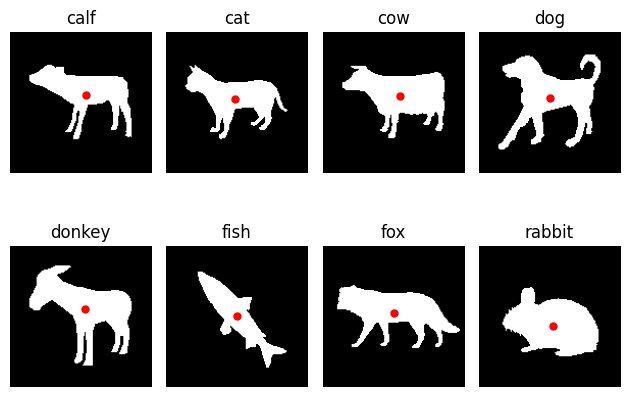

In [ ]:
fig, axes = plt.subplots(2, 4)
for a in axes.flatten():
    a.axis("off")
for a, (k,v) in zip(axes.flatten(), BaseImages.items()):
    a.imshow(v, cmap="gray")
    mo = cv2.moments(v)
    a.plot(mo["m10"]/mo["m00"], mo["m01"]/mo["m00"], "o", color="red", markersize=5)
    a.set_title(k)
plt.tight_layout()
plt.show()

In [ ]:
# Rotate images 20 degrees CCW
if not os.path.exists("Rot20"):
    os.mkdir("Rot20")
for name, img in BaseImages.items():
    rotated = scipy.ndimage.rotate(img, 20, reshape=False)
    # plt.imsave(f"Rot20/{name}.png", rotated, cmap="gray")

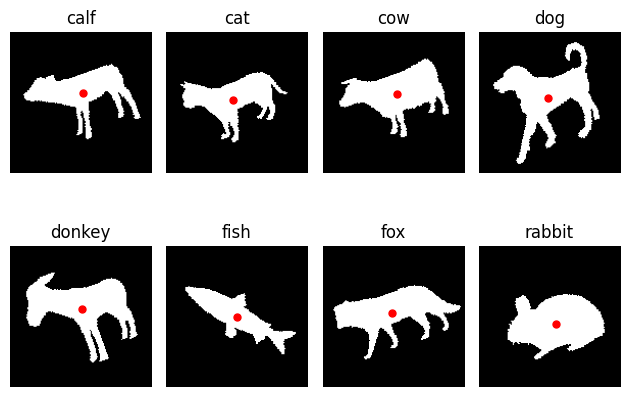

In [ ]:
Rot20Images = {os.path.splitext(file)[0]: (plt.imread(f"Rot20/{file}")[:,:,0] > 0.5).astype(np.float32) for file in ImageNames}

fig, axes = plt.subplots(2, 4)
for a in axes.flatten():
    a.axis("off")
for a, (k,v) in zip(axes.flatten(), Rot20Images.items()):
    a.imshow(v, cmap="gray")
    mo = cv2.moments(v)
    a.plot(mo["m10"]/mo["m00"], mo["m01"]/mo["m00"], "o", color="red", markersize=5)
    a.set_title(k)
plt.tight_layout()
plt.show()

In [ ]:
# Move images to the lower right
import scipy.ndimage


if not os.path.exists("Shifted"):
    os.mkdir("Shifted")
for name, img in BaseImages.items():
    y = np.argmin(np.diff(np.max(img, axis=1)))
    x = np.argmin(np.diff(np.max(img, axis=0)))
    shifted = scipy.ndimage.shift(img, (MaxDim - y - 2, MaxDim - x - 2))
    # plt.imsave(f"Shifted/{name}.png", shifted, cmap="gray")

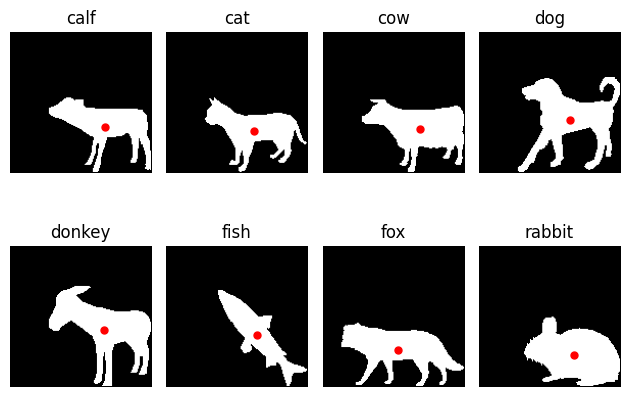

In [ ]:
ShiftedImages = {os.path.splitext(file)[0]: plt.imread(f"Shifted/{file}")[:,:,0] for file in ImageNames}

fig, axes = plt.subplots(2, 4)
for a in axes.flatten():
    a.axis("off")
for a, (k,v) in zip(axes.flatten(), ShiftedImages.items()):
    a.imshow(v, cmap="gray")
    mo = cv2.moments(v)
    a.plot(mo["m10"]/mo["m00"], mo["m01"]/mo["m00"], "o", color="red", markersize=5)
    a.set_title(k)
plt.tight_layout()
plt.show()

In [ ]:
# Shrink images 50%
if not os.path.exists("ZoomOut"):
    os.mkdir("ZoomOut")
for name, img in BaseImages.items():
    zoomed = scipy.ndimage.zoom(img, 0.5)
    # plt.imsave(f"ZoomOut/{name}.png", zoomed, cmap="gray")

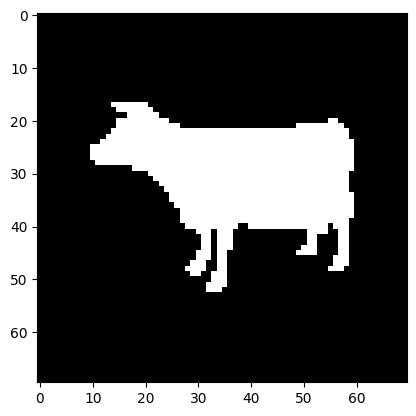

In [ ]:
ZoomOutImages = {os.path.splitext(file)[0]: plt.imread(f"ZoomOut/{file}")[:,:,0] for file in ImageNames}
plt.imshow(ZoomOutImages["cow"], "gray")

In [ ]:
# Add noise
if not os.path.exists("Noise10dB"):
    os.mkdir("Noise10dB")
for name, img in BaseImages.items():
    NoiseVar = np.var(img) / 10**(10/10)
    noisy = img + np.random.normal(0, np.sqrt(NoiseVar), img.shape)
    plt.imsave(f"Noise10dB/{name}.png", noisy, cmap="gray")

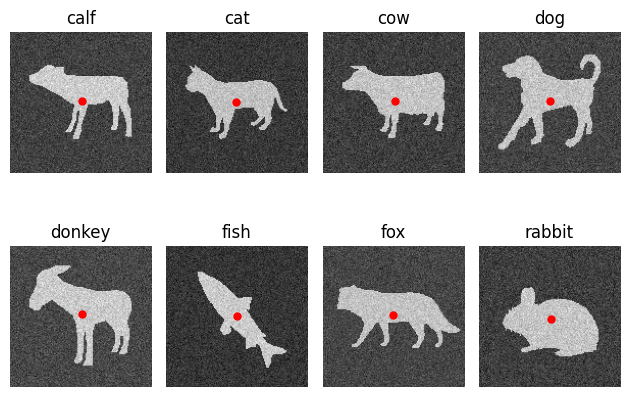

In [ ]:
Noise10dBImages = {os.path.splitext(file)[0]: plt.imread(f"Noise10dB/{file}")[:,:,0] for file in ImageNames}
fig, axes = plt.subplots(2, 4)
for a in axes.flatten():
    a.axis("off")
for a, (k,v) in zip(axes.flatten(), Noise10dBImages.items()):
    a.imshow(v, cmap="gray")
    mo = cv2.moments(v)
    a.plot(mo["m10"]/mo["m00"], mo["m01"]/mo["m00"], "o", color="red", markersize=5)
    a.set_title(k)
plt.tight_layout()
plt.show()

In [ ]:
# Add noise
if not os.path.exists("Noise5dB"):
    os.mkdir("Noise5dB")
for name, img in BaseImages.items():
    NoiseVar = np.var(img) / 10**(5/10)
    noisy = img + np.random.normal(0, np.sqrt(NoiseVar), img.shape)
    plt.imsave(f"Noise5dB/{name}.png", noisy, cmap="gray")

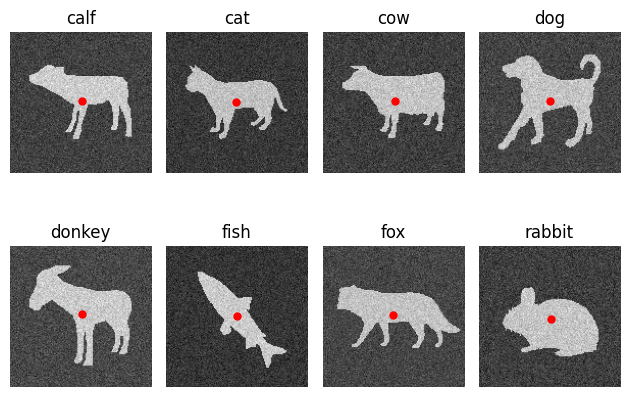

In [ ]:
Noise5dBImages = {os.path.splitext(file)[0]: plt.imread(f"Noise10dB/{file}")[:,:,0] for file in ImageNames}
fig, axes = plt.subplots(2, 4)
for a in axes.flatten():
    a.axis("off")
for a, (k,v) in zip(axes.flatten(), Noise5dBImages.items()):
    a.imshow(v, cmap="gray")
    mo = cv2.moments(v)
    a.plot(mo["m10"]/mo["m00"], mo["m01"]/mo["m00"], "o", color="red", markersize=5)
    a.set_title(k)
plt.tight_layout()
plt.show()

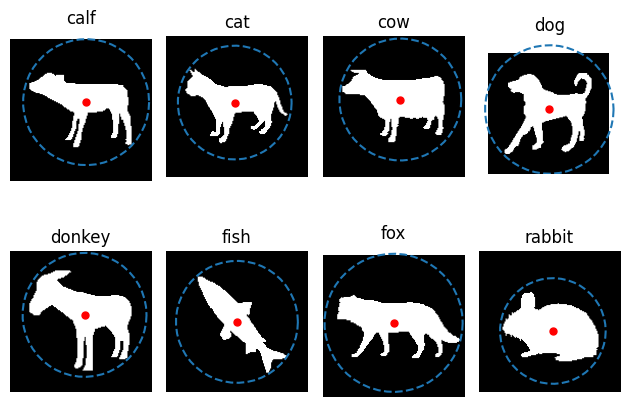

In [ ]:
Radius = {"calf": 62, "cat": 56, "cow": 60, "dog": 74, "donkey": 61, "fish": 60, "fox": 68, "rabbit": 52}
angle = np.linspace(0, 2*np.pi)

fig, axes = plt.subplots(2, 4)
for a in axes.flatten():
    a.axis("off")
for a, (k,v) in zip(axes.flatten(), BaseImages.items()):
    a.imshow(v, cmap="gray")
    mo = cv2.moments(v)
    x, y = mo["m10"]/mo["m00"], mo["m01"]/mo["m00"]
    a.plot(x, y, "o", color="red", markersize=5)
    X = x + Radius[k] * np.cos(angle)
    Y = y + Radius[k] * np.sin(angle)
    a.plot(X,Y, "--", markersize=.5)
    a.set_title(k)
plt.tight_layout()
plt.show()


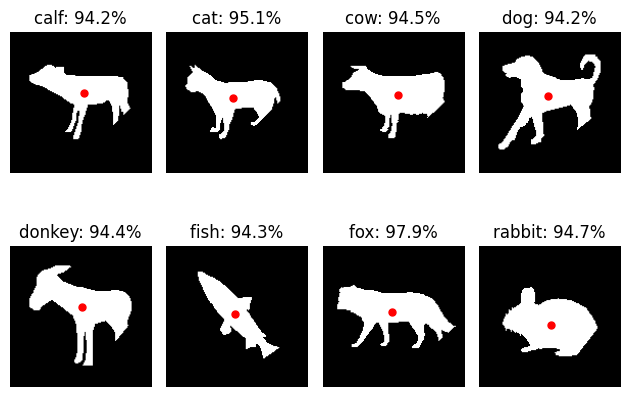

In [ ]:
OccludeImages = {os.path.splitext(file)[0]: plt.imread(f"Occlude/{file}")[:,:,0] for file in ImageNames}
fig, axes = plt.subplots(2, 4)
for a in axes.flatten():
    a.axis("off")
for a, (k,v) in zip(axes.flatten(), OccludeImages.items()):
    a.imshow(v, cmap="gray")
    mo = cv2.moments(v)
    a.plot(mo["m10"]/mo["m00"], mo["m01"]/mo["m00"], "o", color="red", markersize=5)
    a.set_title(f"{k}: {mo["m00"]/cv2.moments(BaseImages[k])["m00"]:.1%}")
plt.tight_layout()
plt.show()